In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
np.random.seed(42)
data = pd.DataFrame({
    "hours_studied": np.random.randint(2, 10, 50),
    "attendance": np.random.randint(50, 100, 50)
})
data.head()

,hours_studied,attendance
0,8,96
1,5,93
2,6,52
3,8,86
4,4,56


In [ ]:
x = data[["hours_studied","attendance"]]
model = KMeans(n_clusters=3, random_state=42,n_init=10)
data["cluster"] = model.fit_predict(x)
data.head()

,hours_studied,attendance,cluster
0,8,96,1
1,5,93,1
2,6,52,0
3,8,86,1
4,4,56,0


In [ ]:
score = silhouette_score(x,data["cluster"])
print("silhouette score:",score)


silhouette score: 0.5598046834718658


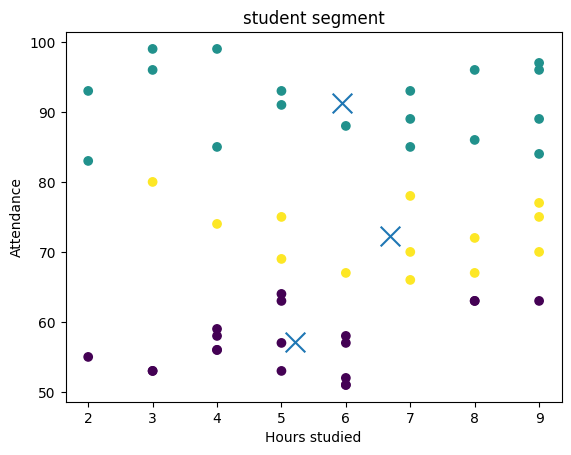

In [ ]:
plt.scatter(data["hours_studied"],data["attendance"],c=data["cluster"])
centers = model.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],marker="x",s=200)
plt.xlabel("Hours studied")
plt.ylabel("Attendance")
plt.title("student segment")
plt.show()

In [ ]:
new_student = [[6,80]]
predicted_cluster = model.predict(new_student)
print("predicted cluster:",predicted_cluster[0])

predicted cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
data.groupby("cluster").mean()

,hours_studied,attendance
cluster,,
0,5.210526,57.105263
1,5.944444,91.222222
2,6.692308,72.307692
